# Linear Regression — A Step-by-Step Guide

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davidrajm/DSA-DL-FDP/blob/main/Day%2002%20-%20Machine%20Learning%20-%20Dr%20Arun%20RajKumar/Lab%20Sessions/07_k-means.ipynb)


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.decomposition       import PCA
from sklearn.cluster             import KMeans
from sklearn.preprocessing       import StandardScaler

from sklearn.datasets import make_regression
from sklearn.utils import Bunch

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


In [12]:
X_raw, y_continuous = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=7,
    noise=20,
    random_state=42
)


# ── 2. Bin continuous y into 3 discrete classes ───────────────────────────────
#    Low / Medium / High  (based on equal-frequency quantile bins)
y_binned, bin_edges = pd.cut(
    y_continuous,
    bins=3,
    labels=[0, 1, 2],   # 0=Low, 1=Medium, 2=High
    retbins=True
)
y = y_binned.astype(int)

feature_names = [f'feature_{i}' for i in range(X_raw.shape[1])]

dataset = Bunch(
    data=X_raw,
    target=y,
    feature_names=feature_names,
    DESCR="Synthetic regression dataset via make_regression"
)

# Now this works exactly like any sklearn dataset
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

X = df.drop(columns='target')   # Feature matrix
y = df['target']

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)



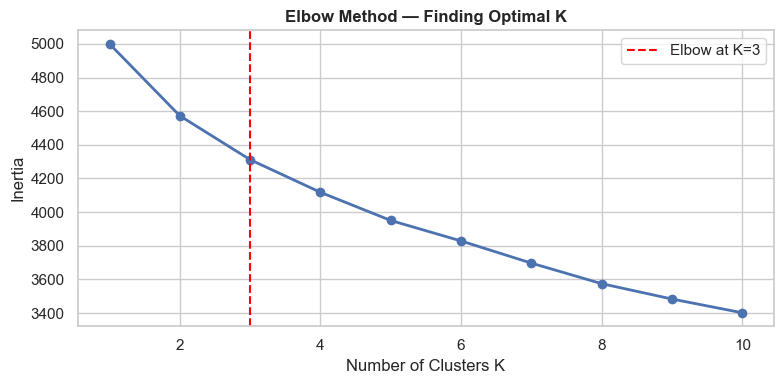

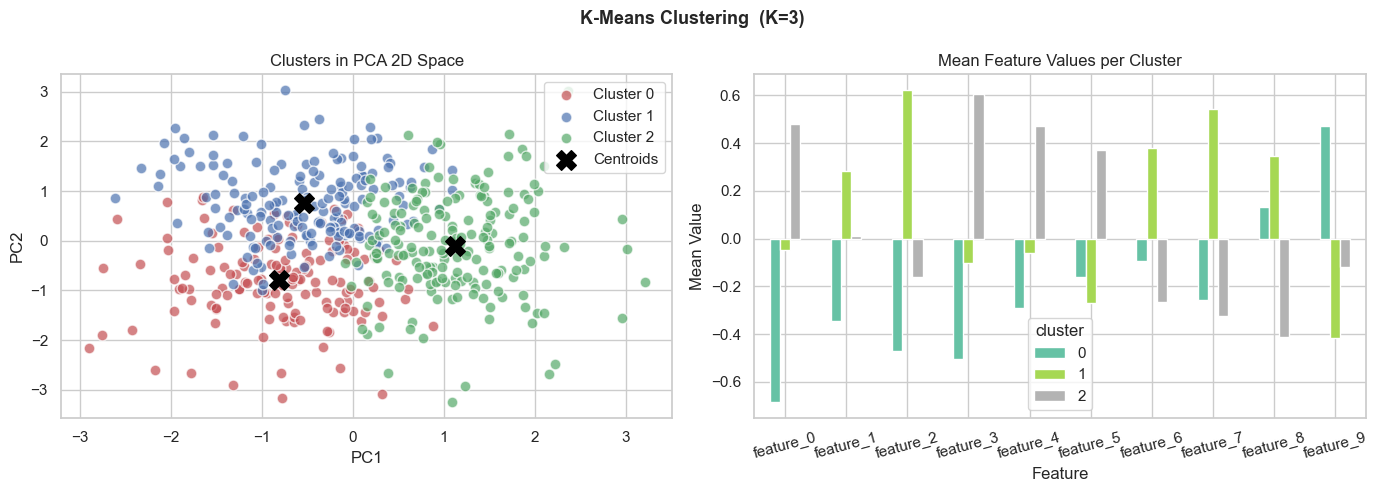

In [14]:
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, "bo-", lw=2)
plt.axvline(3, color="red", linestyle="--", lw=1.5, label="Elbow at K=3")
plt.xlabel("Number of Clusters K"); plt.ylabel("Inertia")
plt.title("Elbow Method — Finding Optimal K", fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()

# K-Means with K=3
kmeans   = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca_vis  = PCA(n_components=2)
X_vis    = pca_vis.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("K-Means Clustering  (K=3)", fontsize=13, fontweight="bold")

palette = ["#C44E52", "#4C72B0", "#55A868"]
for c, col in enumerate(palette):
    mask = clusters == c
    axes[0].scatter(X_vis[mask,0], X_vis[mask,1],
                    color=col, label=f"Cluster {c}", alpha=0.7, edgecolors="white", s=60)

centers_2d = pca_vis.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_2d[:,0], centers_2d[:,1],
                marker="X", s=200, color="black", zorder=5, label="Centroids")
axes[0].set_title("Clusters in PCA 2D Space")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

df_c = df[feature_names].copy()
df_c["cluster"] = clusters
cluster_means   = df_c.groupby("cluster")[feature_names].mean()
cluster_means.T.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set_title("Mean Feature Values per Cluster")
axes[1].set_xlabel("Feature"); axes[1].set_ylabel("Mean Value")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()
